In [1]:
# Configuration OpenMP
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
from torch.utils.data import Dataset, DataLoader, random_split

# Imports des modules locaux
from data_loading import *
from models import *
from training import *
from visualization import *
from evaluation import *

from IPython.display import HTML

print("✓ Modules rechargés avec succès")

✓ Modules rechargés avec succès


### Env configuration

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

# Data path configuration
project_root = Path(os.getcwd()).parent  # go back from modular -> NFTM_for_Physic -> NFTM
data_dir = project_root / "Data"
print(f"Data directory: {data_dir}")

models_dir = project_root / "saved_models"

WINDOW_SIZE = 10

Device used: cuda
Data directory: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\Data


### Dataset Configuration and Loading

In [3]:
# ========== DATASET CONFIGURATION ==========
# Change this parameter to switch between datasets:
# - "simple": Uses BurgersDatasetSimple (one trajectory per viscosity from Data/ folder)
# - "generated": Uses BurgersViscosityDataset (multiple samples from generated_2d_burgers/ folder)

DATASET_TYPE = "generated"  # Use the 2D (x,y,t) generated dataset

batch_size = 4
history_len = 3  # Only used for "generated" dataset

# Count samples per viscosity
def count_samples_per_nu(data_dir):
    npz_files = list(data_dir.glob("*.npz"))
    nu_counts = {}
    
    for path in npz_files:
        data = np.load(path)
        nu = float(data['nu'])
        nu_counts[nu] = nu_counts.get(nu, 0) + 1
    
    return sorted(nu_counts.items())

  
print("📁 Using BurgersViscosityDataset2D with separate train/test folders")
# Paths to your separate train and test folders
train_data_dir = project_root / "saved_dataset" / "generated_2d_burgers" / "train"
test_data_dir = project_root / "saved_dataset" / "generated_2d_burgers" / "test"
print(f"Train data directory: {train_data_dir}")

# Create DataLoaders (2D)
train_loader, test_loader = create_generated_dataloaders_from_folders_2d(
    train_dir=str(train_data_dir),
    test_dir=str(test_data_dir),
    history_len=history_len,
    batch_size=batch_size
)

print(f"Train loader created with {len(train_loader.dataset)} samples")
print(f"Test loader created with {len(test_loader.dataset)} samples")

# Infer (C, H, W) from one batch
sample_init, sample_traj, sample_nu = next(iter(train_loader))
print(f"Sample trajectory shape: {tuple(sample_traj.shape)}")
C = sample_traj.shape[2]
H = sample_traj.shape[3]
W = sample_traj.shape[4]
print(f"Inferred grid: C={C}, H={H}, W={W}")

📁 Using BurgersViscosityDataset2D with separate train/test folders
Train data directory: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\saved_dataset\generated_2d_burgers\train
Train loader created with 73 samples
Test loader created with 60 samples
Sample trajectory shape: (4, 128, 1, 64, 64)
Inferred grid: C=1, H=64, W=64


📌 Aperçu des données chargées (train)
📂 Loaded file: sample_0020_x-5.00_+5.00_y-5.00_+5.00_v2.737_T128.npz
✅ Vidéo sauvegardée: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\video\train_sample.gif


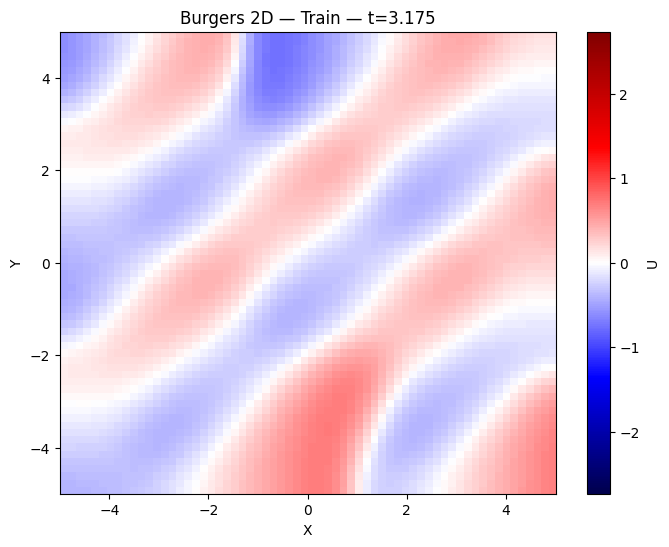

📌 Aperçu des données chargées (test)
📂 Loaded file: sample_0022_x-5.00_+5.00_y-5.00_+5.00_v2.222_T128.npz
✅ Vidéo sauvegardée: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\video\test_sample.gif


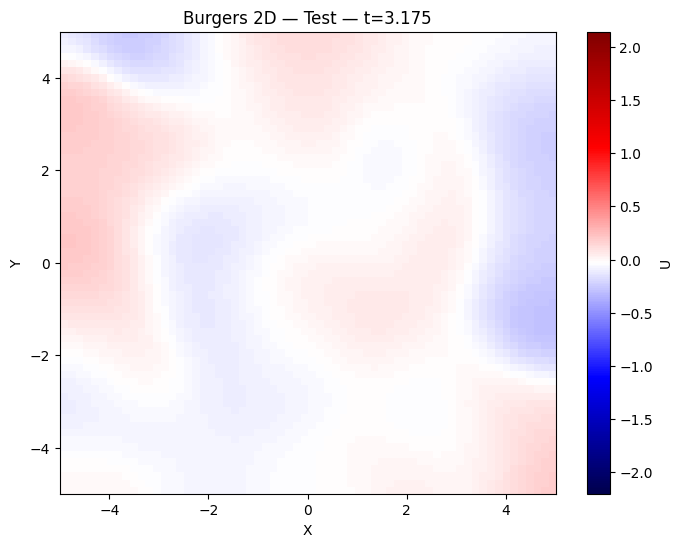

In [4]:
# Preview loaded 2D data using the 2D visualization helper
import sys
from pathlib import Path

project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Physical_Simulator.burger2D import visualize_random_sample_2d

DATA_CMAP = "seismic"

video_dir = project_root / "video"
video_dir.mkdir(parents=True, exist_ok=True)

print("📌 Aperçu des données chargées (train)")
visualize_random_sample_2d(
    out_dir=str(train_data_dir),
    title_prefix="Burgers 2D — Train",
    cmap=DATA_CMAP,
    show_animation=True,
    save_video_path=str(video_dir / "train_sample.gif"),
 )

print("📌 Aperçu des données chargées (test)")
visualize_random_sample_2d(
    out_dir=str(test_data_dir),
    title_prefix="Burgers 2D — Test",
    cmap=DATA_CMAP,
    show_animation=True,
    save_video_path=str(video_dir / "test_sample.gif"),
 )

### Load model

In [5]:
# Model configuration
patch_radius = 0  # For 2D data, patch size = C * (2r+1)^2
patch_size = C * (2 * patch_radius + 1) ** 2
chunk_size = 5
corr_clip = 0.3

LOAD_MODEL_NAME = None

# --- TCAN 2D --- #
model = TCAN2D(
    window_size=history_len,
    corr_clip=corr_clip,
    use_viscosity=True,
    in_channels=C,
)

# --- Load a saved model # 
# LOAD_MODEL_NAME = "tcan2d.pth"  # Set to filename like "my_model.pth" to load a model

if LOAD_MODEL_NAME is not None:
    print(f"📥 Loading model from: {LOAD_MODEL_NAME}")
    model = torch.load(models_dir / LOAD_MODEL_NAME, map_location=device, weights_only=False)
    print(f"✓ Model loaded successfully")

model = model.to(device)

print(f"Model information:")
print(f"  - Patch radius: {patch_radius}")
print(f"  - Patch size: {patch_size}")
print(f"  - Output channels: {C}")
print(f"  - Number of parameters: {sum(p.numel() for p in model.parameters())}")
print(f"\nModel architecture:")
print(model)

Model information:
  - Patch radius: 0
  - Patch size: 1
  - Output channels: 1
  - Number of parameters: 17441

Model architecture:
TCAN2D(
  (attn): CausalTemporalAttention2D(
    (embedding): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GELU(approximate='none')
    )
    (query_proj): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (key_proj): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (val_proj): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (out_proj): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (norm): GroupNorm(4, 32, eps=1e-05, affine=True)
  )
  (nu_embed): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (film_gamma): Linear(in_features=32, out_features=32, bias=True)
  (film_beta): Linear(in_features=32, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Co

### Model training

In [6]:
num_epochs = 40

print(f"🚀 Starting training for {num_epochs} epochs with {DATASET_TYPE} dataset...")
print("=" * 60)

# Train TCAN 2D
model, history, history_len = train_tcan_2d(
    train_loader,
    test_loader,
    history_len=history_len,
    num_epochs=num_epochs,
    corr_clip=corr_clip,
 )
training_mode = "TCAN 2D"
train_losses = history.get('loss', [])

print(f"\n Training completed!")
print(f" Dataset used : {DATASET_TYPE}")
print(f" Model        : {model.__class__.__name__}")
print(f" Mode         : {training_mode}")
final_loss = train_losses[-1] if train_losses else float('nan')
print(f" Final loss   : {final_loss:.6f}")

🚀 Starting training for 40 epochs with generated dataset...
TRAINING TCAN 2D
History length: 3


Training TCAN 2D:   2%|▎         | 1/40 [00:01<01:05,  1.67s/it]

Epoch 0: Loss=0.0485, Rollout=4


Training TCAN 2D:  28%|██▊       | 11/40 [00:09<00:24,  1.18it/s]

Epoch 10: Loss=0.0195, Rollout=4


...

Epoch 20: Loss=0.0169, Rollout=8


Training TCAN 2D:  78%|███████▊  | 31/40 [00:50<00:51,  5.75s/it]

Epoch 30: Loss=0.0157, Rollout=125


Training TCAN 2D: 100%|██████████| 40/40 [03:23<00:00,  5.08s/it]


 Training completed!
 Dataset used : generated
 Model        : TCAN2D
 Mode         : TCAN 2D
 Final loss   : 0.015684


### Loss funciton

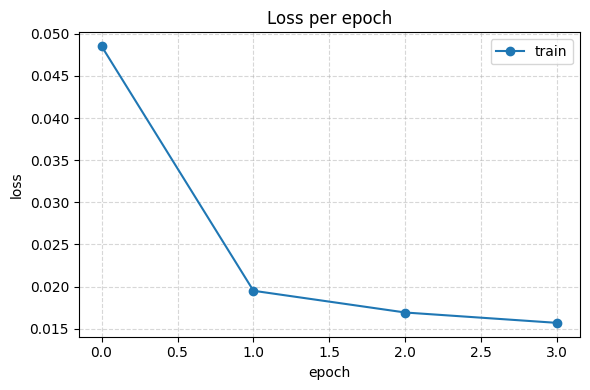

Final loss: 0.015684
Loss reduction: 67.69%


In [7]:
plot_losses(train_losses)

print(f"Final loss: {train_losses[-1]:.6f}")
print(f"Loss reduction: {((train_losses[0] - train_losses[-1])/train_losses[0]*100):.2f}%")

## Visualization

In [8]:
# Choose a single nu target to use for both visualization and evaluation
# Supported values: float (e.g. 0.01), 'min', 'max', 'idx:N', 'random', 'list', or None
PLOT_NU = 'random'  # change this value to pick a specific sample or 'list' for available nus

# Resolve selected_nu once and store it globally
eval_loader = test_loader if test_loader is not None else train_loader
loader_type = "test" if test_loader is not None else "train"

print(f"🎯 Resolving nu target using loader: {loader_type} and PLOT_NU={PLOT_NU}")
selected_nu = resolve_nu_target(eval_loader, plot_nu=PLOT_NU, selected_nu=None, list_nus=True, verbose=True)

if selected_nu is None:
    print("No specific nu selected; visualization/evaluation will use default (first sample from loader).")
else:
    print(f"Global selected_nu set: {selected_nu}")


🎯 Resolving nu target using loader: test and PLOT_NU=random
Loader contains 1 unique nu values: [0.10000000149011612]
Global selected_nu set: 0.10000000149011612


In [9]:
# Generate predictions for visualization (2D)
# Use test_loader if available, otherwise fall back to train_loader

# Use the selected_nu set by the single selection cell above if present
selected_nu_local = globals().get('selected_nu', None)

eval_loader = test_loader if test_loader is not None else train_loader
loader_type = "test" if test_loader is not None else "train"

print(f"🔍 Generating predictions using {loader_type} data...")

if selected_nu_local is None:
    print("No global selected_nu set; the first sample from the loader will be used for visualization (nu_target=None).")
else:
    print(f"Using selected nu target for visualization: {selected_nu_local}")

true_traj, pred_traj, nu_value = generate_model_predictions_2d(
    model, 
    eval_loader, 
    device, 
    patch_radius, 
    verbose=True, 
    chunk_size=chunk_size,
    nu_target=selected_nu_local,
    list_nus=False,
    fallback_to_first=True,
 )

# Visualize trajectories (2D animation)
video_dir = project_root / "video"
video_dir.mkdir(parents=True, exist_ok=True)

base_gif_path = video_dir / f"prediction_nu_{nu_value:.4f}_{loader_type}.gif"
plot_trajectories_2d(
    true_traj,
    pred_traj,
    title_suffix=f" (nu={nu_value:.4f}, {loader_type} data)",
    channel=0,
    interval_ms=60,
    show_animation=True,
    save_video_path=str(base_gif_path),
 )

merged_gif_path = video_dir / f"prediction_nu_{nu_value:.4f}_{loader_type}_merged.gif"
combine_gifs_horizontal(
    [
        str(base_gif_path).replace(".gif", "_true.gif"),
        str(base_gif_path).replace(".gif", "_pred.gif"),
        str(base_gif_path).replace(".gif", "_err.gif"),
    ],
    str(merged_gif_path),
 )
print(f"✅ GIF fusionne: {merged_gif_path}")

🔍 Generating predictions using test data...
Using selected nu target for visualization: 0.10000000149011612
Generating 2D predictions for nu = 0.1000
True trajectory shape: torch.Size([128, 1, 64, 64])
Model type: TCAN2D
  step 0/123


ValueError: not enough values to unpack (expected 5, got 3)

## Evaluation

📊 Evaluating model performance on test data...
Using selected nu target for evaluation: 0.10000000149011612
Evaluation metrics (2D):
  - PSNR: -6.950 dB
  - SSIM: 0.041
  - MSE: 4.954077
  - R²: 0.1218


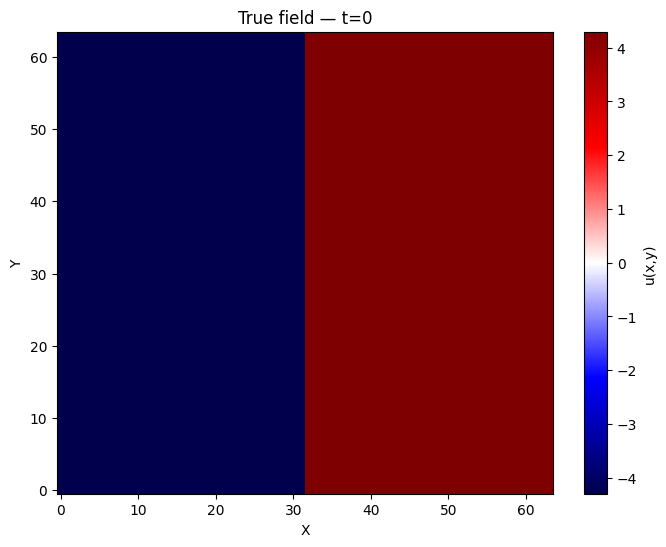

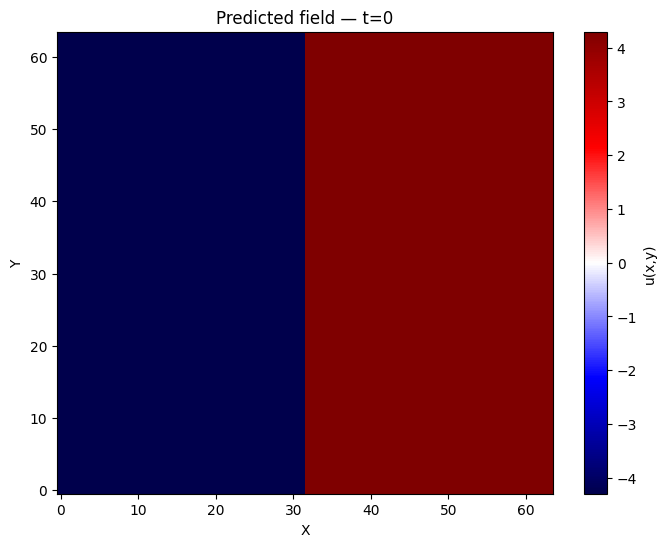

🧪 Aperçu des données d'évaluation (test)
📂 Loaded file: sample_0029_x-5.00_+5.00_y-5.00_+5.00_v4.327_T128.npz


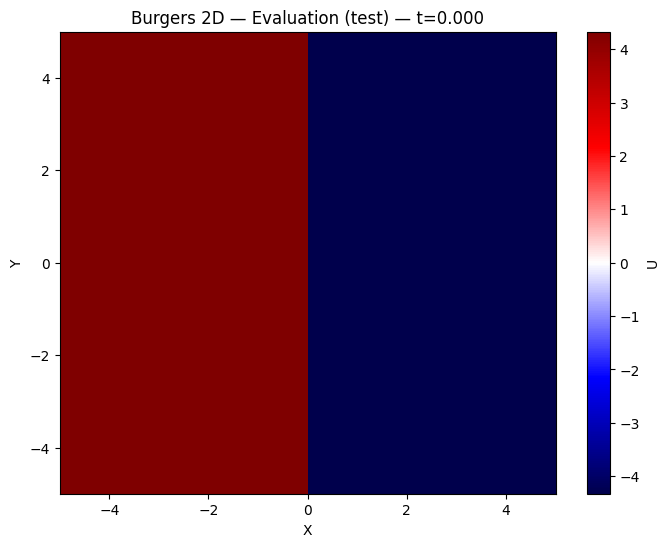

In [ ]:
# Complete evaluation with dedicated function (2D)
# Use test_loader if available, otherwise fall back to train_loader
eval_loader = test_loader if test_loader is not None else train_loader
loader_type = "test" if test_loader is not None else "train"

print(f"📊 Evaluating model performance on {loader_type} data...")

# Use the same selected nu set by the single selection cell (selected_nu)
selected_nu_local = globals().get('selected_nu', None)

# Do not call resolve_nu_target here - central selection is in the single cell
if selected_nu_local is None:
    eval_nu_target = None
    print("No global selected_nu set for evaluation; using default (first sample from loader).")
else:
    eval_nu_target = selected_nu_local
    print(f"Using selected nu target for evaluation: {eval_nu_target}")

evaluation_results = evaluate_model_on_sample_2d(
    model,
    eval_loader,
    device,
    patch_radius,
    max_val=1.0,
    val_range=1.0,
    chunk_size=chunk_size,
    nu_target=eval_nu_target,
 )

# Display results with dedicated function
true_traj, pred_traj = display_evaluation_results_2d(
    evaluation_results,
    show_plots=True,
    channel=0,
    interval_ms=60,
    save_video_path=None,
    cmap="seismic",
 )

# Visualize a random sample from the evaluation dataset folder
if "visualize_random_sample_2d" not in globals():
    import sys
    from pathlib import Path
    project_root = Path(os.getcwd()).parent
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    from Physical_Simulator.burger2D import visualize_random_sample_2d

eval_dir = test_data_dir if loader_type == "test" else train_data_dir
print(f"🧪 Aperçu des données d'évaluation ({loader_type})")
visualize_random_sample_2d(
    out_dir=str(eval_dir),
    title_prefix=f"Burgers 2D — Evaluation ({loader_type})",
    show_animation=True
 )

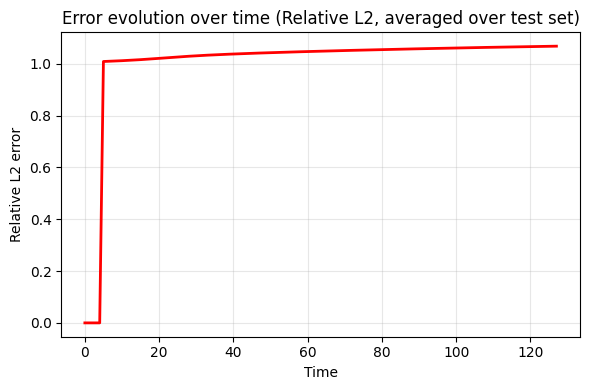

Mean error_per_time shape: (128,)

📊 Relative L2 Error (averaged over test set):
   Global mean error: 1.005147
   Min error (at any time): 0.000000
   Max error (at any time): 1.068171


In [ ]:
if test_loader is not None:
    mean_error_per_time = error_evolution_on_loader_2d(
        model,
        test_loader,
        device,
        patch_radius=patch_radius,
        chunk_size=chunk_size,
        show_plot=True,   # met à False si tu veux juste les valeurs
        metric="rel_l2"
    )
    print(f"Mean error_per_time shape: {mean_error_per_time.shape}")
    
    # Calcul de l'erreur L2 moyenne globale
    mean_l2_error = np.mean(mean_error_per_time)
    print(f"\n📊 Relative L2 Error (averaged over test set):")
    print(f"   Global mean error: {mean_l2_error:.6f}")
    print(f"   Min error (at any time): {np.min(mean_error_per_time):.6f}")
    print(f"   Max error (at any time): {np.max(mean_error_per_time):.6f}")
else:
    print("No test loader available; skipping test set evaluation.")

### Save Model

In [ ]:
# ========== MODEL SAVING ==========
SAVE_MODEL_NAME = "transformers.pth"  

if SAVE_MODEL_NAME is not None:
    print(f"💾 Saving model to: {SAVE_MODEL_NAME}")
    torch.save(model, models_dir / SAVE_MODEL_NAME)
    print(f"✓ Model saved successfully to: {models_dir / SAVE_MODEL_NAME}")
else:
    print("ℹ️  To save the model, set SAVE_MODEL_NAME = 'filename.pth'")
    print(f"   Models will be saved to: {models_dir}")

💾 Saving model to: transformers.pth
✓ Model saved successfully to: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\saved_models\transformers.pth


In [ ]:
# 🔎 Debug: display unique nu values in train/test loaders
try:
    if 'test_loader' in globals() and test_loader is not None:
        print("Test loader unique nu values:", get_loader_nu_values(test_loader))
    if 'train_loader' in globals() and train_loader is not None:
        print("Train loader unique nu values:", get_loader_nu_values(train_loader))
except Exception as e:
    print("Unable to inspect loader nus:", e)

Test loader unique nu values: [0.10000000149011612]
Train loader unique nu values: [0.10000000149011612]
